# Gamma Radiation Attenuation in Lead (Pb)

This notebook analyzes the attenuation of gamma rays in lead shielding.

## Experimental Design

**Status**: Template - waiting for measurement data

### Expected Analysis:
1. Measure gamma ray intensity with intermediate lead thickness
2. Measure gamma ray intensity with large lead thickness
3. Extract mass attenuation coefficient μ/ρ
4. Compare with theoretical values (NIST data)
5. Determine half-value layer (HVL)
6. Analyze beam hardening effects

### Theoretical Background

The intensity of gamma rays through matter follows:
$$I = I_0 e^{-\mu x}$$

Where:
- $I_0$ = incident intensity
- $\mu$ = linear attenuation coefficient (cm⁻¹)
- $x$ = thickness (cm)

Or using mass attenuation coefficient:
$$I = I_0 e^{-(\mu/\rho) \rho x}$$

The **half-value layer (HVL)** is the thickness needed to reduce intensity by 50%:
$$\text{HVL} = \frac{\ln(2)}{\mu}$$

In [ ]:
import glob
import os
import re
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

Fator de normalização do background = 0.11728395061728394


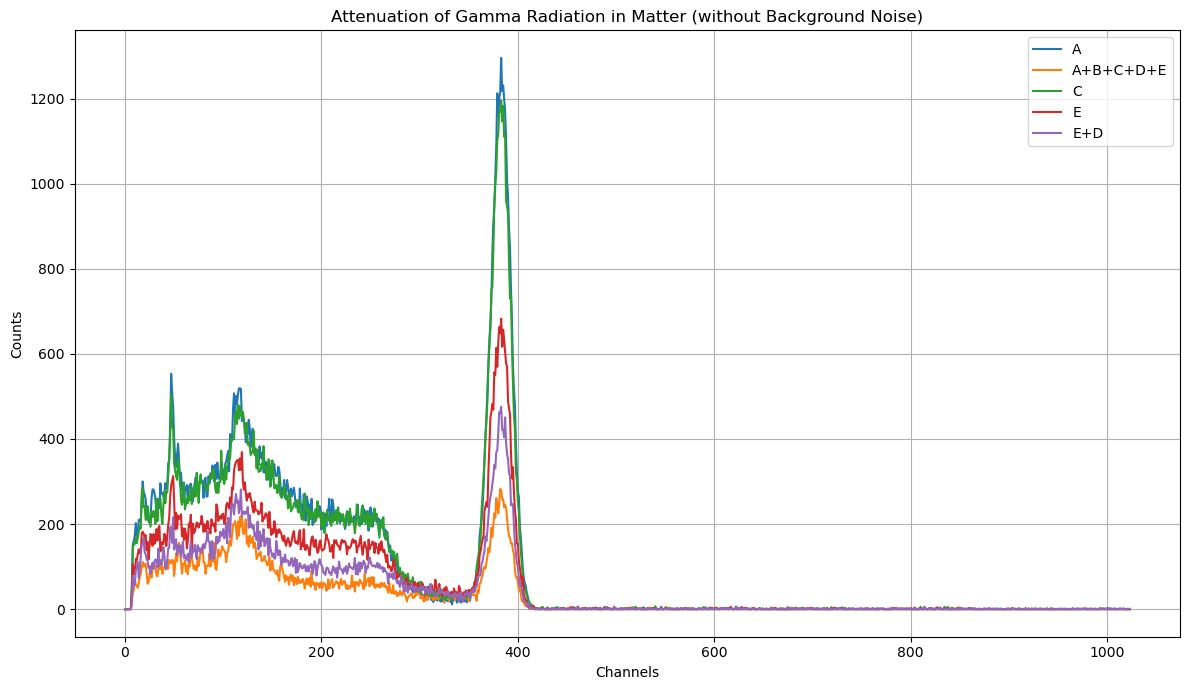


Pico mais alto em A:
  Canal 383  →  Contagens 1296


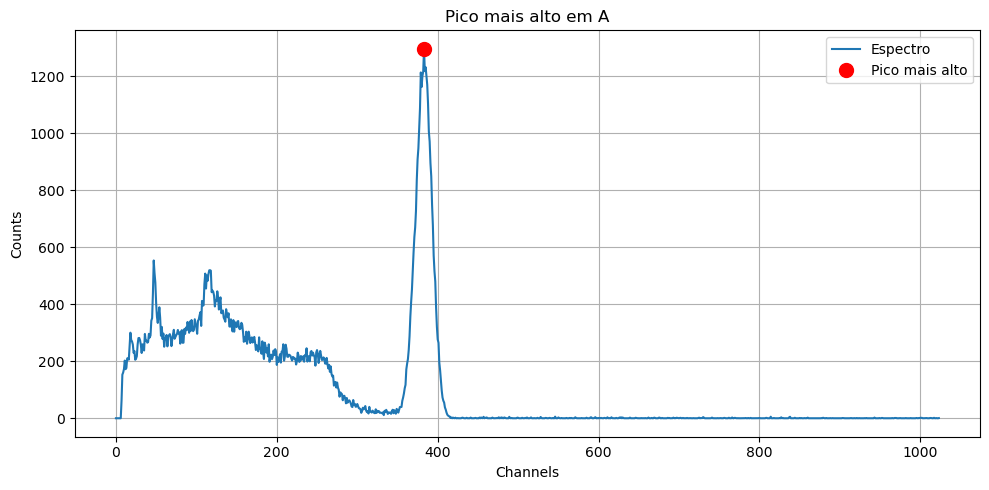


Pico mais alto em A+B+C+D+E:
  Canal 382  →  Contagens 283


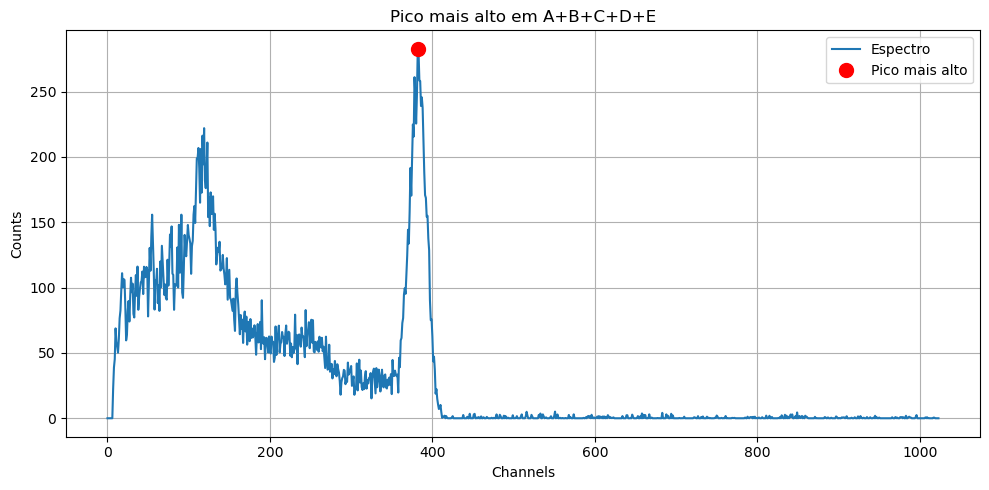


Pico mais alto em C:
  Canal 383  →  Contagens 1196


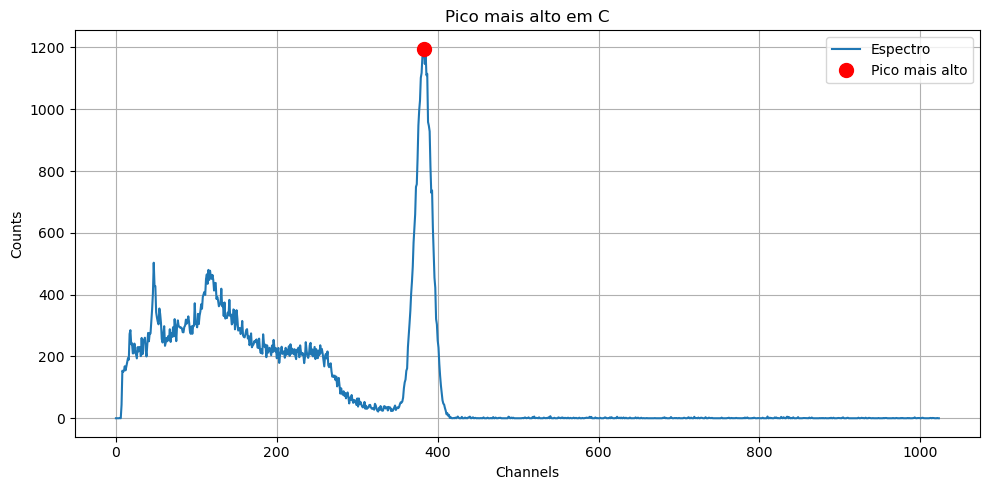


Pico mais alto em E:
  Canal 383  →  Contagens 683


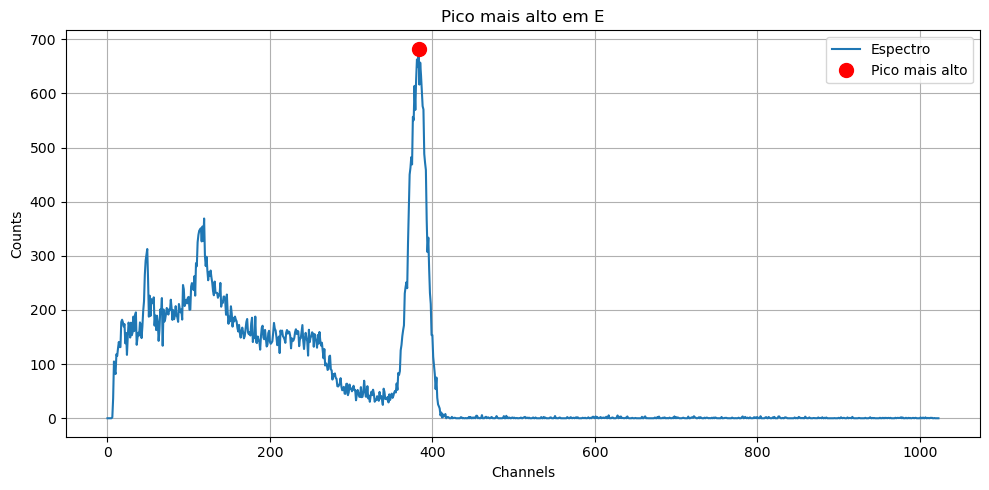


Pico mais alto em E+D:
  Canal 383  →  Contagens 476


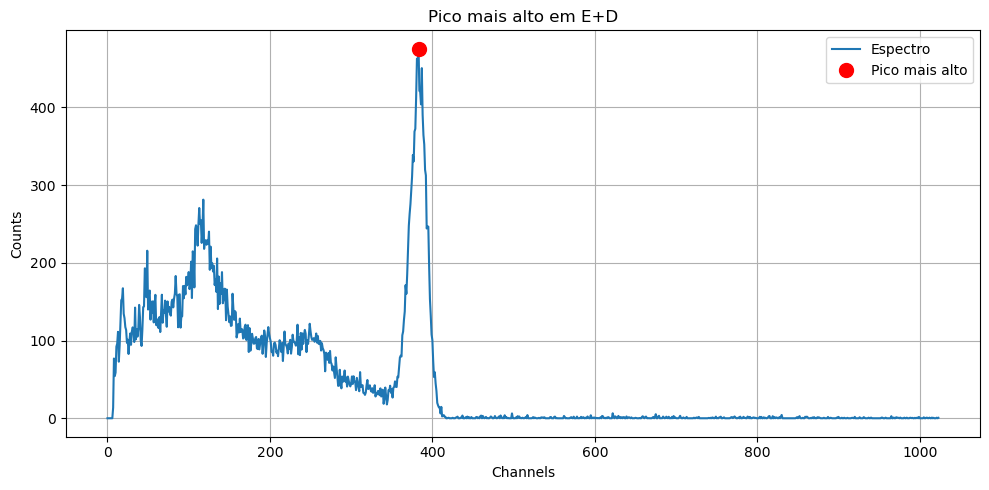


2º Pico mais alto (Fotopico) em Césio-137 (Calibração):
  Canal 387  →  Contagens 7277


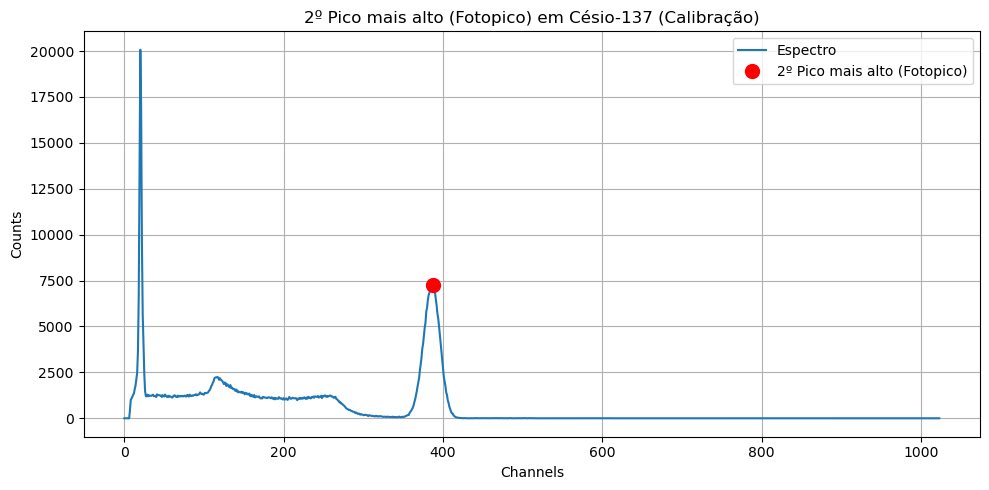

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import glob

# ---------------------------------------------------------
# Dicionário de Nomes - EDITA AQUI AS TUAS LEGENDAS!
# ---------------------------------------------------------
nomes_certos = {
    "PBA.ASC": "A",
    "PBALL.ASC": "A+B+C+D+E",
    "PBC.ASC": "C",
    "PBE.ASC": "E",
    "PBED.ASC": "E+D",
    "CESIOCAL.ASC": "Césio-137 (Calibração)"
}

# ---------------------------------------------------------
# 1. Função para ler ficheiros .ASC no formato real
# ---------------------------------------------------------
def read_asc(path):
    channels = []
    counts = []

    with open(path, "r") as f:
        lines = f.readlines()

    # encontrar onde começam os dados
    start = None
    for i, line in enumerate(lines):
        if line.strip().startswith("Chn"):
            start = i + 1
            break

    if start is None:
        raise ValueError(f"Formato inesperado em {path}")

    # ler linhas de dados
    for line in lines[start:]:
        parts = line.strip().split(",")
        if len(parts) < 2:
            continue
        try:
            ch = int(parts[0])
            ct = int(parts[1])
            channels.append(ch)
            counts.append(ct)
        except:
            continue

    return {
        "path": path,
        "channels": np.array(channels),
        "counts": np.array(counts)
    }

# ---------------------------------------------------------
# 2. Função para remover background normalizado
# ---------------------------------------------------------
def subtract_background(source_spectrum, background_spectrum, scale_bg):
    src_ct = source_spectrum['counts']
    bg_ct  = background_spectrum['counts']

    corrected = src_ct - scale_bg * bg_ct
    corrected[corrected < 0] = 0

    return {
        'path': f"{source_spectrum['path']} (bg-subtracted)",
        'channels': source_spectrum['channels'],
        'counts': corrected
    }

# ---------------------------------------------------------
# 3. Tempos de aquisição
# ---------------------------------------------------------
T_BG = 2106   # segundos
T_SRC = 247   # segundos

scale_bg = T_SRC / T_BG
print("Fator de normalização do background =", scale_bg)

# ---------------------------------------------------------
# 4. Carregar background
# ---------------------------------------------------------
background = read_asc("BACKGROUND.ASC")

# ---------------------------------------------------------
# 5. Carregar todos os PB* e CESIOCAL.ASC
# ---------------------------------------------------------
files = glob.glob("PB*.ASC") + ["CESIOCAL.ASC"]
spectra = [read_asc(f) for f in files]

# ---------------------------------------------------------
# 6. Subtrair background normalizado
# ---------------------------------------------------------
corrected_spectra = [
    subtract_background(spec, background, scale_bg)
    for spec in spectra
]

# ---------------------------------------------------------
# 7. Plot de todos os espectros PB* (IGNORAR CESIOCAL)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

for spec in corrected_spectra:
    if "CESIOCAL" in spec["path"].upper():
        continue  # IGNORA CESIOCAL NO PLOT
        
    # Limpa a tag para procurar o nome no dicionário
    nome_ficheiro = spec['path'].replace(" (bg-subtracted)", "")
    label_grafico = nomes_certos.get(nome_ficheiro, nome_ficheiro)
    
    plt.plot(spec['channels'], spec['counts'], label=label_grafico)

plt.xlabel("Channels")
plt.ylabel("Counts")
plt.title("Attenuation of Gamma Radiation in Matter (without Background Noise)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Detetar o pico de interesse
# ---------------------------------------------------------
for spec in corrected_spectra:
    counts = spec['counts']
    channels = spec['channels']

    # Vai buscar o nome bonito também para os prints e títulos individuais
    nome_ficheiro = spec['path'].replace(" (bg-subtracted)", "")
    nome_bonito = nomes_certos.get(nome_ficheiro, nome_ficheiro)

    peaks, props = find_peaks(counts, height=np.max(counts)*0.05, distance=10)

    if len(peaks) == 0:
        print(f"\nNenhum pico encontrado em {nome_bonito}")
        continue

    # Ordenar os índices dos picos com base no número de contagens (ordem crescente)
    sorted_peak_indices = np.argsort(counts[peaks])

    # Lógica condicional: se for Césio e tiver 2 ou mais picos, pega o 2º maior.
    if "CESIOCAL" in nome_ficheiro.upper() and len(peaks) >= 2:
        target_peak = peaks[sorted_peak_indices[-2]] # -1 é o maior, -2 é o segundo maior
        label_pico = "2º Pico mais alto (Fotopico)"
    else:
        target_peak = peaks[sorted_peak_indices[-1]] # Maior pico
        label_pico = "Pico mais alto"

    print(f"\n{label_pico} em {nome_bonito}:")
    print(f"  Canal {channels[target_peak]:.0f}  →  Contagens {counts[target_peak]:.0f}")

    plt.figure(figsize=(10, 5))
    plt.plot(channels, counts, label="Espectro")
    plt.plot(channels[target_peak], counts[target_peak], "ro", markersize=10, label=label_pico)
    plt.title(f"{label_pico} em {nome_bonito}")
    plt.xlabel("Channels")
    plt.ylabel("Counts")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
count_n = 7277
array_counts = np.array([
    476, 683, 1196, 283, 1296]) # E + D, 
thicknesses = np.array([11057, 7042, 2014.7, 16278.5, 947.7])  

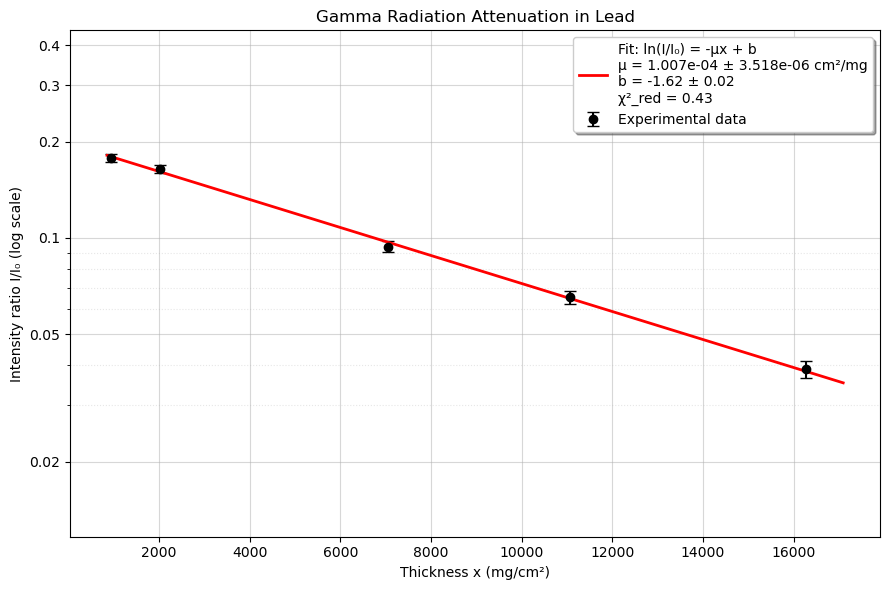

=== FIT RESULTS ===
Attenuation coefficient μ = 1.00719e-04 ± 3.51797e-06 cm²/mg
b = -1.623 ± 0.024
Reduced chi-square = 0.430


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

# ---------------------------------------------------------
# 1. Experimental data
# ---------------------------------------------------------
I0 = 7277
I = np.array([476, 683, 1196, 283, 1296])
x = np.array([11057, 7042, 2014.7, 16278.5, 947.7])  # mg/cm²

ratio_I = I / I0

# ---------------------------------------------------------
# 2. Linearization: ln(I/I0)
# ---------------------------------------------------------
y_log = np.log(ratio_I)
sigma_log = np.sqrt(1/I + 1/I0)

# ---------------------------------------------------------
# 3. Linear fit: ln(I/I0) = -μ x + b
# ---------------------------------------------------------
def linear_log(x, mu, b):
    return -mu * x + b

popt, pcov = curve_fit(linear_log, x, y_log, sigma=sigma_log, absolute_sigma=True)
mu, b = popt
err_mu, err_b = np.sqrt(np.diag(pcov))

# ---------------------------------------------------------
# 4. Chi-square
# ---------------------------------------------------------
y_fit_log = linear_log(x, mu, b)
chi2 = np.sum(((y_log - y_fit_log) / sigma_log) ** 2)
dof = len(x) - 2
chi2_red = chi2 / dof

# ---------------------------------------------------------
# 5. Plot
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

x_fit = np.linspace(min(x)*0.9, max(x)*1.05, 300)
y_fit = np.exp(-mu * x_fit + b)

sigma_linear = ratio_I * sigma_log

plt.errorbar(
    x, ratio_I, yerr=sigma_linear,
    fmt='ko', markersize=6, capsize=4,
    label='Experimental data'
)

label_fit = (
    f"Fit: ln(I/I₀) = -μx + b\n"
    f"μ = {mu:.3e} ± {err_mu:.3e} cm²/mg\n"
    f"b = {b:.2f} ± {err_b:.2f}\n"
    f"χ²_red = {chi2_red:.2f}"
)

plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=label_fit)

# ---------------------------------------------------------
# Improved vertical scale (log) with custom ticks
# ---------------------------------------------------------
ax = plt.gca()
ax.set_yscale('log')

# Expanded vertical range
ymin = min(ratio_I) * 0.3
ymax = max(ratio_I) * 2.5
ax.set_ylim(ymin, ymax)

# Custom major ticks
major_ticks = [0.4, 0.3, 0.2, 0.1, 0.05, 0.02]
ax.set_yticks(major_ticks)

# Minor ticks between major ticks
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=np.linspace(1, 9, 9)))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))

plt.grid(True, which="major", linestyle="-", alpha=0.5)
plt.grid(True, which="minor", linestyle=":", alpha=0.3)

plt.xlabel("Thickness x (mg/cm²)")
plt.ylabel("Intensity ratio I/I₀ (log scale)")
plt.title("Gamma Radiation Attenuation in Lead")
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. Terminal output
# ---------------------------------------------------------
print("=== FIT RESULTS ===")
print(f"Attenuation coefficient μ = {mu:.5e} ± {err_mu:.5e} cm²/mg")
print(f"b = {b:.3f} ± {err_b:.3f}")
print(f"Reduced chi-square = {chi2_red:.3f}")

